# Simulation_CLP

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, FO_RT, Delay_RT
from package_LAB import PID_RT, LL_RT, IMC_Tuning


# Load data

In [58]:
nameFile = 'RT_PID_FF_2026-03-26-23h12.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

tm = data['t'].values
MVm = data['MV'].values
MVPm = data['MVP'].values
MVIm = data['MVI'].values
MVDm = data['MVD'].values
MVFFm = data['MVFF'].values
PVm = data['PV'].values

In [59]:
Kp = 0.36
Tp1 = 170.82
Tp2 = 26.55
thetap = 13.31

Kd = 0.31
Td1 = 161.20
Td2 = 32.3
thetad = 15.75

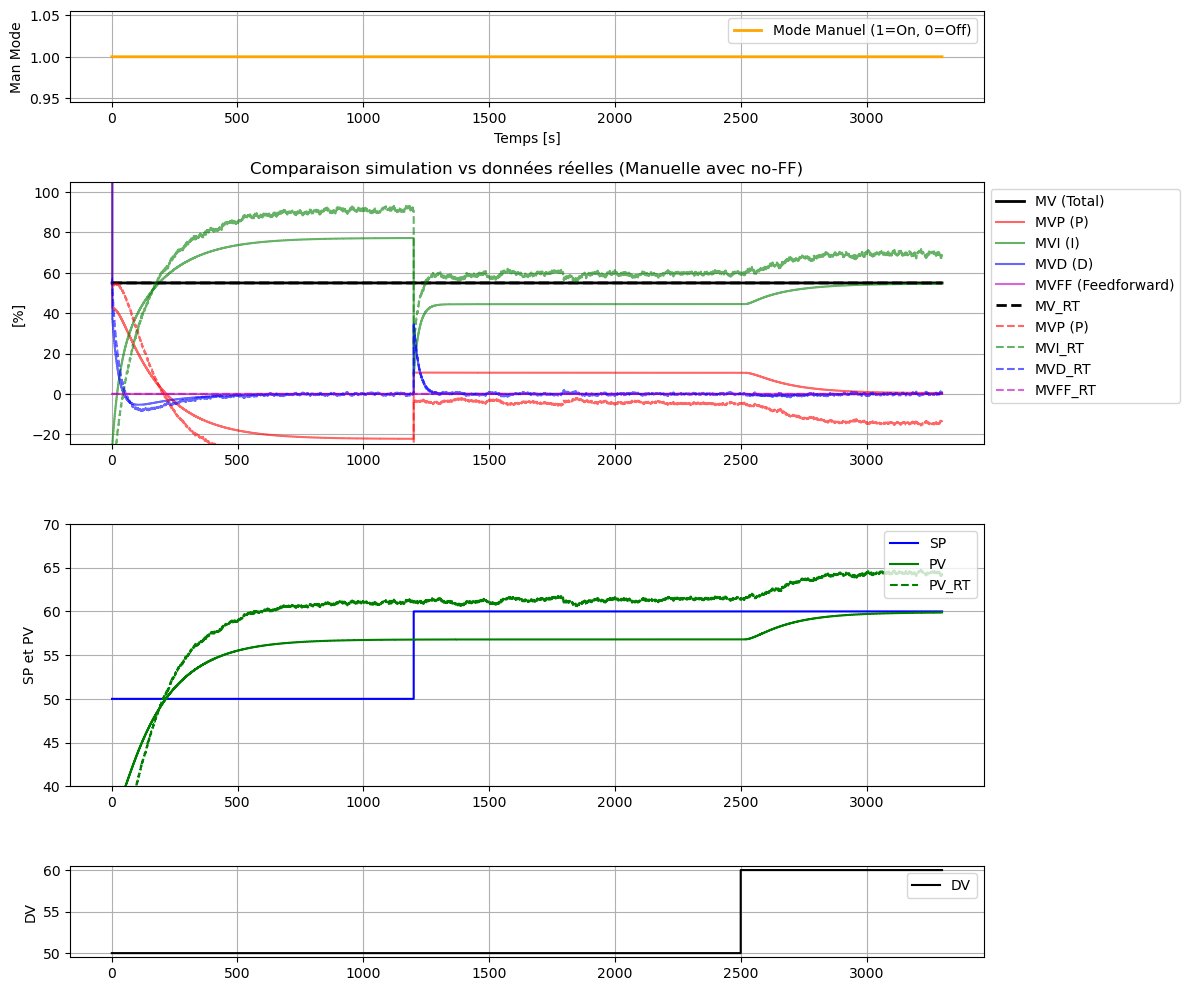

PID Tuning : Kc=3.28, Ti=197.37, Td=22.98, Td/Ti=0.12
Dernières valeurs : P=0.43, I=54.59, D=-0.02, FF=0.00


In [60]:
TSim = 3300
Ts = 1 
N = int(TSim/Ts) + 1

#Parametres
PV0 = 55
MV0= 50
DV0 = 50
K_FF = -Kd / Kp
theta_FF = max(0, thetad - thetap)

alpha = 0.9
gamma = 0.9
Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2= Tp2, tauc=gamma*Tp1 , model='SOPDT')
MVMin = 0
MVMax = 100
booléan = False


t = []
DV = []

#FEEDFORWARD
DV_delta = []
DV_delay = []
MVFF_step1 = [] 
MVFF = []

#PID
E = []
SP = []
Man = []
MVMan = []
MV = []
MVP = [] 
MVI = [] 
MVD = []

#PROCESS
MVDelayp = []
PV1p = []
PV2p = []
PV = []

#D(s)
MVDelayd = []
PV1d = []
PV2d = []


DVPath = {0: 50, 2500: 60, TSim: 60}
SPPath = {0: 50, 1200: 60, TSim: 60}
#ManPath = {0: True, 100: False, 1500: False, TSim: False}
ManPath = {0: True, TSim: True}
MVManPath = {0: 55, TSim: 55}

for i in range(1, N):

    t.append(i * Ts)

    SelectPath_RT(DVPath, t, DV)
    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(ManPath, t, Man)
    SelectPath_RT(MVManPath, t, MVMan) 
    
    #LL
    DV_delta.append(DV[-1] - DV0)
    Delay_RT(DV_delta, theta_FF, Ts, DV_delay)
    LL_RT(DV_delay, K_FF, Tp1, Td1, Ts, MVFF_step1, method='EBD')
    if booléan == True:
        LL_RT(MVFF_step1, 1.0, Tp2, Td2, Ts, MVFF, method='EBD')
    else:
        LL_RT(MVFF_step1, 0, Tp2, Td2, Ts, MVFF, method='EBD')
        
    #PID
    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF = booléan)

    #P(s)
    Delay_RT(MV, thetap, Ts, MVDelayp, MV0)
    FO_RT(MVDelayp, Kp, Tp1, Ts, PV1p)
    FO_RT(PV1p, 1, Tp2, Ts, PV2p)
   
    #D(s)
    Delay_RT(DV_delta, thetad, Ts, MVDelayd)
    FO_RT(MVDelayd, Kd, Td1, Ts, PV1d)
    FO_RT(PV1d, 1, Td2, Ts, PV2d)

    PV.append(PV2p[-1] + PV2d[-1] + PV0-Kp*MV0)


plt.figure(figsize=(12, 10))

#MV
ax2 = plt.subplot2grid((12, 1), (2, 0), rowspan=4)
ax2.step(t, MV, 'k-', lw=2, label='MV (Total)', where='post')
ax2.step(t, MVP, 'r-', label='MVP (P)', where='post', alpha=0.6)
ax2.step(t, MVI, 'g-', label='MVI (I)', where='post', alpha=0.6)
ax2.step(t, MVD, 'b-', label='MVD (D)', where='post', alpha=0.6)
ax2.step(t, MVFF, 'm-', label='MVFF (Feedforward)', where='post', alpha=0.6)
ax2.step(tm, MVm, 'k--', lw=2, label='MV_RT', where='post')
ax2.step(tm, MVPm, 'r--', label='MVP (P)', where='post', alpha=0.6)
ax2.step(tm, MVIm, 'g--', label='MVI_RT', where='post', alpha=0.6)
ax2.step(tm, MVDm, 'b--', label='MVD_RT', where='post', alpha=0.6)
ax2.step(tm, MVFFm, 'm--', label='MVFF_RT', where='post', alpha=0.6)
ax2.set_ylabel('[%]')
ax2.set_title('Comparaison simulation vs données réelles (Manuelle avec no-FF)')
ax2.set_ylim(-25, 105)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True)

#SP, PV
ax3 = plt.subplot2grid((12, 1), (6, 0), rowspan=4)
ax3.step(t, SP, 'b-', label='SP', where='post')
ax3.step(t, PV, 'g-', label='PV', where='post')
ax3.step(tm, PVm, 'g--', label='PV_RT', where='post')
#ax3.step(t, E, 'r-', label='Erreur', where='post')
ax3.set_ylabel('SP et PV')
ax3.set_ylim(40, 70)
ax3.legend(loc='upper right')
ax3.grid(True)

#DV
ax4 = plt.subplot2grid((12, 1), (10, 0), rowspan=2)
ax4.step(t, DV, 'k-', label='DV', where='post')
ax4.set_ylabel('DV')
ax4.legend(loc='upper right')
ax4.grid(True)
 

#Mode Manuel
ax1 = plt.subplot2grid((12, 1), (0, 0), rowspan=2)
ax1.step(t, [int(m) for m in Man], 'orange', lw=2, label='Mode Manuel (1=On, 0=Off)', where='post')
ax1.set_ylabel('Man Mode')
ax1.set_xlabel('Temps [s]')
ax1.legend(loc='upper right')
ax1.grid(True)


plt.tight_layout()
plt.show()


print(f"PID Tuning : Kc={Kc:.2f}, Ti={Ti:.2f}, Td={Td:.2f}, Td/Ti={Td/Ti:.2f}")
print(f"Dernières valeurs : P={MVP[-1]:.2f}, I={MVI[-1]:.2f}, D={MVD[-1]:.2f}, FF={MVFF[-1]:.2f}")
